<a href="https://colab.research.google.com/github/Rodrivdlc/Sistema-basado-en-Inteligencia-Artificial-para-la-detecci-n-de-enfermedades-en-cultivos/blob/main/notebooks/05_entrenamiento_multicultivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import shutil
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/TFG/dataset/archive.zip" -d "/content/dataset"

In [ ]:
dataset_path = "/content/dataset/PlantVillage"

In [ ]:
clases = sorted([
    clase
    for clase in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, clase))
])

print("Número de clases:", len(clases))

for clase in clases:
    print(clase)

Número de clases: 15
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [ ]:
for clase in clases:
    ruta = os.path.join(dataset_path, clase)

    imagenes = [
        archivo
        for archivo in os.listdir(ruta)
        if archivo.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{clase}: {len(imagenes)}")

Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


In [ ]:
split_base = "/content/multicrop_split"

train_path = os.path.join(split_base, "train")
val_path = os.path.join(split_base, "val")
test_path = os.path.join(split_base, "test")

for ruta in [train_path, val_path, test_path]:
    os.makedirs(ruta, exist_ok=True)

In [ ]:
random.seed(42)

for clase in clases:

    clase_path = os.path.join(dataset_path, clase)

    imagenes = [
        img
        for img in os.listdir(clase_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(imagenes)

    total = len(imagenes)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_imgs = imagenes[:train_end]
    val_imgs = imagenes[train_end:val_end]
    test_imgs = imagenes[val_end:]

    for destino_base, lista in [
        (train_path, train_imgs),
        (val_path, val_imgs),
        (test_path, test_imgs)
    ]:

        destino_clase = os.path.join(
            destino_base,
            clase
        )

        os.makedirs(
            destino_clase,
            exist_ok=True
        )

        for imagen in lista:

            shutil.copy2(
                os.path.join(clase_path, imagen),
                os.path.join(destino_clase, imagen)
            )

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14440 files belonging to 15 classes.
Found 3097 files belonging to 15 classes.
Found 3101 files belonging to 15 classes.


In [ ]:
class_names = train_ds.class_names

print("Número de clases:", len(class_names))

for i, clase in enumerate(class_names):
    print(i, clase)

Número de clases: 15
0 Pepper__bell___Bacterial_spot
1 Pepper__bell___healthy
2 Potato___Early_blight
3 Potato___Late_blight
4 Potato___healthy
5 Tomato_Bacterial_spot
6 Tomato_Early_blight
7 Tomato_Late_blight
8 Tomato_Leaf_Mold
9 Tomato_Septoria_leaf_spot
10 Tomato_Spider_mites_Two_spotted_spider_mite
11 Tomato__Target_Spot
12 Tomato__Tomato_YellowLeaf__Curl_Virus
13 Tomato__Tomato_mosaic_virus
14 Tomato_healthy


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs
)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 0.7258 - loss: 0.8840 - val_accuracy: 0.8379 - val_loss: 0.5021
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.8529 - loss: 0.4629 - val_accuracy: 0.8696 - val_loss: 0.3987
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8734 - loss: 0.3884 - val_accuracy: 0.8799 - val_loss: 0.3568
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8840 - loss: 0.3551 - val_accuracy: 0.8792 - val_loss: 0.3633
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8859 - loss: 0.3406 - val_accuracy: 0.8951 - val_loss: 0.3151
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.8935 - loss: 0.3164 - val_accuracy: 0.8944 - val_loss: 0.3196
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.8986 - loss: 0.3026 - val_accuracy: 0.8957 - val_loss: 0.3049
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8992 - loss: 0.2980 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(
    f"Test accuracy: {test_accuracy * 100:.2f}%"
)

print(
    f"Test loss: {test_loss:.4f}"
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8868 - loss: 0.3242
Test accuracy: 88.68%
Test loss: 0.3242


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.91      0.99      0.95       150
                     Pepper__bell___healthy       1.00      0.96      0.98       222
                      Potato___Early_blight       0.99      0.91      0.95       150
                       Potato___Late_blight       0.89      0.95      0.92       150
                           Potato___healthy       1.00      0.83      0.90        23
                      Tomato_Bacterial_spot       0.90      0.87      0.88       320
                        Tomato_Early_blight       0.86      0.60      0.71       150
                         Tomato_Late_blight       0.93      0.84      0.88       287
                           Tomato_Leaf_Mold       0.73      0.91      0.81       143
                  Tomato_Septoria_leaf_spot       0.79      0.88      0.83       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.79

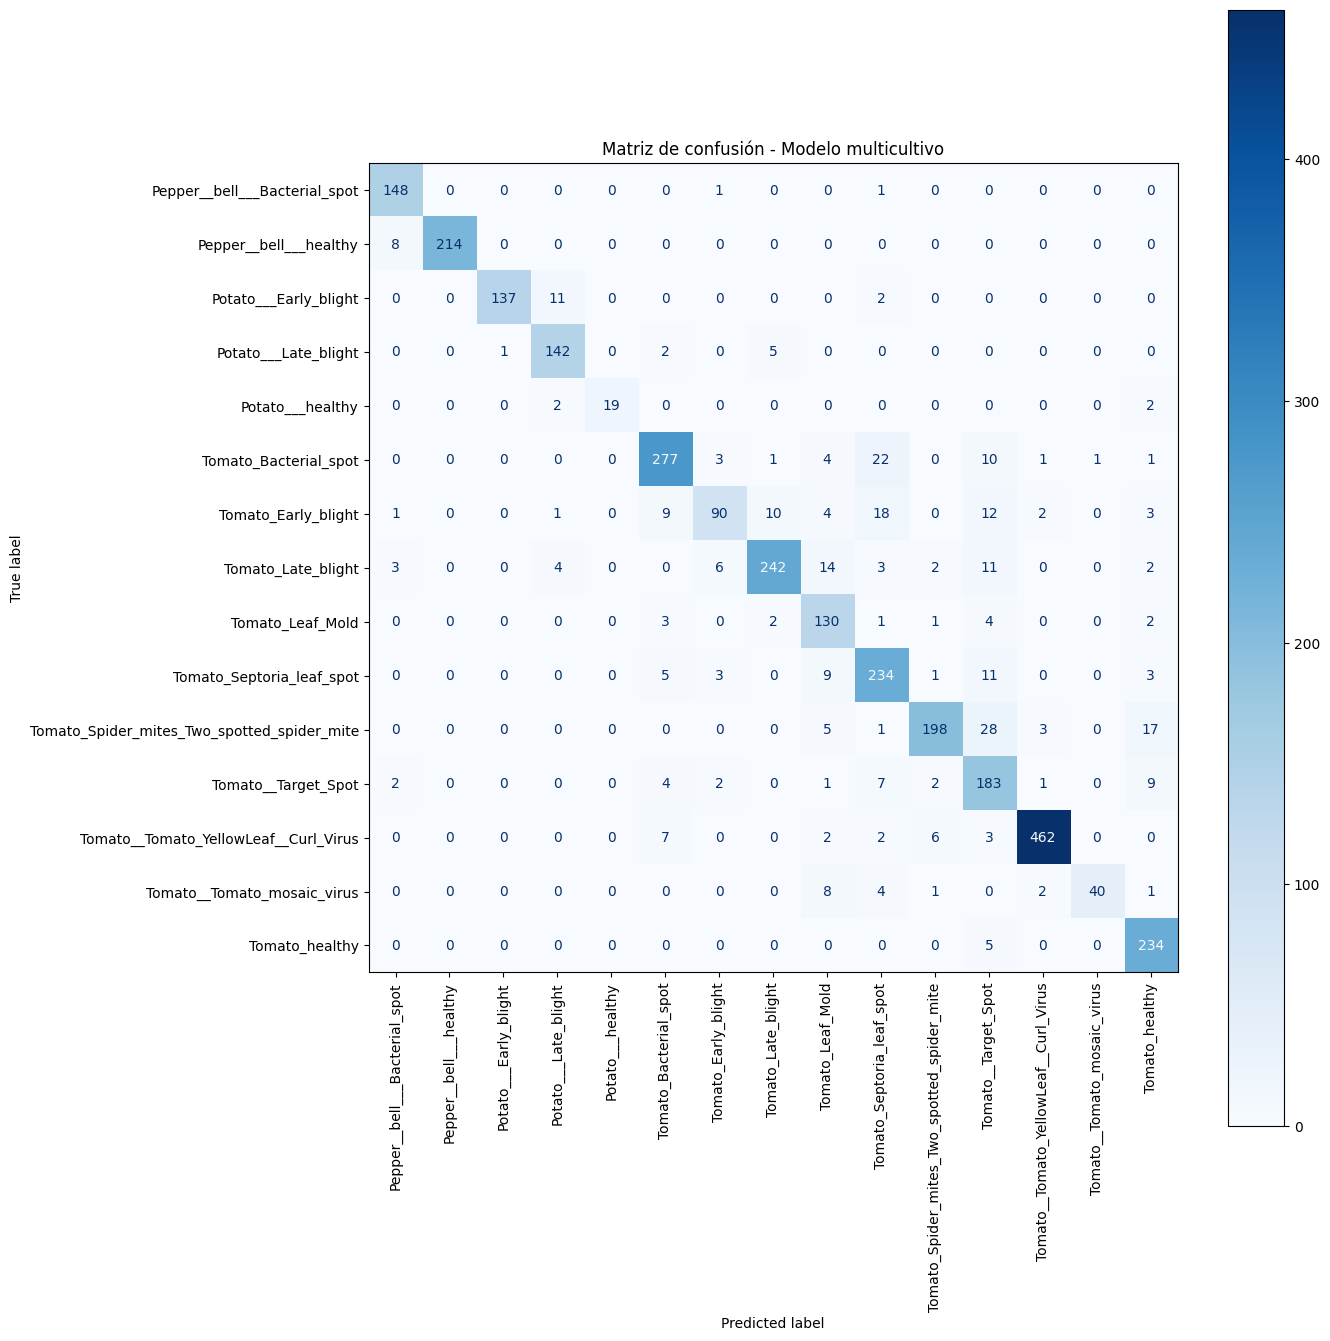

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de confusión - Modelo multicultivo")
plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
print("Capas totales:", len(base_model.layers))

print(
    "Capas entrenables:",
    len([
        layer
        for layer in base_model.layers
        if layer.trainable
    ])
)

Capas totales: 154
Capas entrenables: 54


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 67s 114ms/step - accuracy: 0.7534 - loss: 0.9850 - val_accuracy: 0.9012 - val_loss: 0.2939
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 50s 110ms/step - accuracy: 0.8691 - loss: 0.3984 - val_accuracy: 0.8944 - val_loss: 0.3076
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8947 - loss: 0.3171 - val_accuracy: 0.9012 - val_loss: 0.2814
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9092 - loss: 0.2667 - val_accuracy: 0.9128 - val_loss: 0.2503
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9258 - loss: 0.2207 - val_accuracy: 0.9219 - val_loss: 0.2285
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9343 - loss: 0.2018 - val_accuracy: 0.9209 - val_loss: 0.2182
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9429 - loss: 0.1706 - val_accuracy: 0.9212 - val_loss: 0.2217
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9454 - loss: 0

In [ ]:
test_loss_fine, test_accuracy_fine = model.evaluate(
    test_ds
)

print(
    f"Test accuracy después de fine-tuning: "
    f"{test_accuracy_fine * 100:.2f}%"
)

print(
    f"Test loss: {test_loss_fine:.4f}"
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9387 - loss: 0.2049
Test accuracy después de fine-tuning: 93.87%
Test loss: 0.2049


In [ ]:
y_true_fine = []
y_pred_fine = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_fine.extend(labels.numpy())
    y_pred_fine.extend(predicted_classes)

y_true_fine = np.array(y_true_fine)
y_pred_fine = np.array(y_pred_fine)

In [ ]:
print(
    classification_report(
        y_true_fine,
        y_pred_fine,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       150
                     Pepper__bell___healthy       1.00      1.00      1.00       222
                      Potato___Early_blight       0.97      1.00      0.98       150
                       Potato___Late_blight       0.97      0.96      0.97       150
                           Potato___healthy       0.96      1.00      0.98        23
                      Tomato_Bacterial_spot       0.95      0.95      0.95       320
                        Tomato_Early_blight       0.95      0.67      0.79       150
                         Tomato_Late_blight       0.97      0.92      0.94       287
                           Tomato_Leaf_Mold       0.98      0.90      0.94       143
                  Tomato_Septoria_leaf_spot       0.87      0.95      0.91       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.85

In [ ]:
model.save(
    "/content/drive/MyDrive/TFG/models/modelo_multicultivo_mobilenetv2_finetuned.keras"
)

In [ ]:
import json

with open(
    "/content/drive/MyDrive/TFG/models/class_names_multicultivo.json",
    "w"
) as f:
    json.dump(class_names, f)